Task 05:Sentiment Analysis on Amazon Reviews

• Description: In this project, you will analyze Amazon product reviews to determine the overall sentiment expressed by customers. The dataset
contains customer feedback in text form, which will be processed,cleaned, and classified into categories like 
positive, negative, or neutral.You will learn how to prepare raw text data for analysis, explore customer opinions 
through visualizations such as word frequency charts and word clouds, and then build machine learning models to
automatically classify review sentiment. This project mirrors how companies leverage customer feedback to improve 
products, services,and user experience.

Learning skills: Data Cleaning for Text, Text Preprocessing, EDA,
Feature Engineering, ML for NLP, Model Evaluation.

• Dummy Dataset: Amazon Product Reviews

Inputs: review_text, optional rating or label.
Levers: preprocessing steps, feature representation (TF-IDF or embeddings), model choice, class mapping 
(binary/multiclass), hyperparams.
Outputs: trained model, eval metrics (accuracy, F1, precision, recall), 
confusion matrix, ROC (binary), example predictions, README.

"""
Sentiment Analysis on Amazon Reviews
Sequential, de-duplicated, and commented so a non-programmer can follow each step.
Save this file and run with: python sentiment_analysis_amazon_reviews.py

Required packages (run once):
pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud joblib imbalanced-learn
# Optional (for advanced embeddings):
# pip install transformers torch sentence-transformers

This script assumes a CSV file named 'amazon.csv' with at least these columns:
- reviewText : the text of the review
- overall    : numeric rating (1-5)

Output produced:
- Trained model saved as 'sentiment_model.pkl'
- TF-IDF vectorizer saved as 'tfidf_vectorizer.pkl'
- Plots shown inline when run in an environment that supports plotting
"""

In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud joblib
# optional (transformers)
!pip install datasets transformers torch sentence-transformers



These commands install all the libraries needed.

pandas, numpy — handle data.

scikit-learn — builds machine learning models.

nltk — cleans and processes text.

matplotlib, seaborn, wordcloud — visualize patterns and trends.

joblib — saves trained models for reuse.
The second line installs advanced NLP tools (optional).

# Import libraries

In [33]:
# ---------------------------
# 1) Imports (single block)
# ---------------------------
import re                         # regular expressions for text cleaning
import os
import joblib                     # save/load models

import pandas as pd               # tabular data handling
import numpy as np                # numeric operations

import matplotlib.pyplot as plt   # plotting
import seaborn as sns             # nicer plots
from wordcloud import WordCloud   # word cloud visualization

import nltk                       # classic NLP toolkit
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

#re is Python’s regular expressions module.

Use it to find, replace, or remove patterns in text (e.g., remove punctuation, keep only 
letters: re.sub(r'[^a-z\s]', '', text)).nltk (Natural Language Toolkit) is a classic NLP 
library.
It provides tokenizers, corpora (stopwords), and lemmatizers.

#nltk
Often you must run nltk.download(...) once to get required data.
Imports the stopword lists (common words like “the”, “is”) which you usually 
remove because they add little meaning.
You typically call stopwords.words('english') to get the list.

#import nltk
nltk (Natural Language Toolkit) is a classic NLP library.
It provides tokenizers, corpora (stopwords), and lemmatizers.
Often you must run nltk.download(...) once to get required data

#from nltk.stem import WordNetLemmatizer
Imports a lemmatizer that reduces words to their dictionary base (e.g., running → run).
Lemmatization helps group word forms so models learn on canonical tokens

#from sklearn.model_selection import train_test_split
train_test_split splits data into training and testing sets.
E.g: 
    X_train, X_test, y_train, y_test = 
    train_test_split(X, y,test_size=0.2, stratify=y, random_state=42).
Ensures you evaluate models on unseen data

#from sklearn.feature_extraction.text import TfidfVectorizer
TfidfVectorizer turns raw text into numeric features using TF-IDF weighting.
It both tokenizes text and creates a sparse matrix of features.
Parameters control vocabulary size (max_features) and n-grams (ngram_range).


#from sklearn.linear_model import LogisticRegression
Imports logistic regression classifier.
Simple, fast, and strong baseline for text classification.
Supports class weights and regularization options.


#from sklearn.pipeline import Pipeline
Pipeline chains preprocessing and model steps into one object.
Example: Pipeline([('tfidf', TfidfVectorizer()), ('clf', LogisticRegression())]).
Makes code cleaner and simplifies training, cross-validation, and saving.


#from sklearn.metrics import classification_report, confusion_matrix
classification_report prints precision, recall, f1, and support per class.
confusion_matrix returns counts of true vs predicted labels so you can plot errors.
Both are essential to understand model strengths and failure modes.

# Load dataset

In [3]:
df = pd.read_csv("amazon.csv")
df.shape

(4915, 12)

In [4]:
df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4,No issues.,23-07-2014,138,0,0,0,0,0.0,0.0
1,1,0mie,5,"Purchased this for my device, it worked as adv...",25-10-2013,409,0,0,0,0,0.0,0.0
2,2,1K3,4,it works as expected. I should have sprung for...,23-12-2012,715,0,0,0,0,0.0,0.0
3,3,1m2,5,This think has worked out great.Had a diff. br...,21-11-2013,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5,"Bought it with Retail Packaging, arrived legit...",13-07-2013,513,0,0,0,0,0.0,0.0


In [5]:
df.columns

Index(['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='object')

<Axes: >

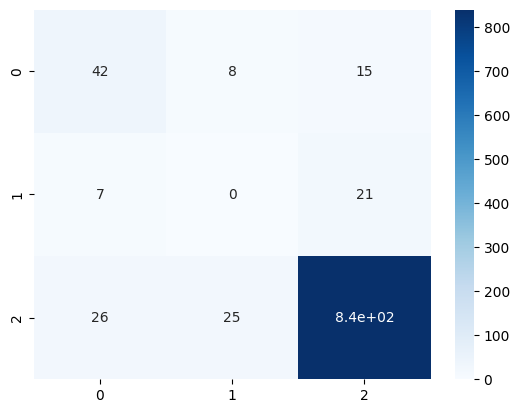

In [57]:
sns.heatmap(cm, annot=True, cmap='Blues')


In [35]:
# Optional: handle class imbalance
try:
    from imblearn.over_sampling import SMOTE
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

In [36]:
# ---------------------------
# 2) NLTK resource downloads
# ---------------------------
# These downloads only need to run once on a machine. If already present they do nothing.
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)


True

In [39]:
# ---------------------------
# 3) Helper functions
# ---------------------------

def rating_to_sentiment(rating):
    """Map numeric rating to sentiment label.

    1-2 => 'negative'
    3   => 'neutral'
    4-5 => 'positive'
    """
    try:
        r = float(rating)
    except Exception:
        return 'neutral'     # fallback when rating missing or invalid

    if r <= 2:
        return 'negative'
    if r == 3:
        return 'neutral'
    return 'positive'
# Text cleaning pipeline explained simply in comments above each step
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()

df['sentiment'] = df['overall'].apply(rating_to_sentiment)
print(df['sentiment'].value_counts())

sentiment
positive    4449
negative     324
neutral      142
Name: count, dtype: int64


Converts numerical ratings into text-based categories:
1–2 → negative
3 → neutral
4–5 → positive
This becomes the target label for sentiment prediction.

In [40]:
def clean_text(text):
    """Convert raw review text into a normalized string suitable for modeling.

    Steps:
    1. Ensure text is a string and set to lowercase.
    2. Remove non-letter characters (keeps spaces and letters only).
    3. Tokenize into words.
    4. Remove stopwords (common words with little meaning).
    5. Remove single-letter tokens (usually not informative).
    6. Lemmatize words (convert different forms to base form).
    7. Rejoin tokens into a single cleaned string.

    Each line is commented to help a non-programmer understand intent.
    """
    if pd.isna(text):
        return ''                     # empty string when input missing

    text = str(text).lower()          # lowercase: 'Hello' -> 'hello'
    text = re.sub(r'[^a-z\s]', ' ', text)  # remove numbers and punctuation

    # simple whitespace tokenizer
    tokens = nltk.word_tokenize(text)

    # remove stopwords and short tokens then lemmatize
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 1]

    return ' '.join(tokens)


In [41]:
# ---------------------------
# 4) Load dataset
# ---------------------------

def load_data(path='amazon.csv'):
    """Load CSV into a pandas DataFrame and show a quick summary."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset file not found: {path}")

    df = pd.read_csv(path)

    # Keep only the two columns we need if present
    expected = ['reviewText', 'overall']
    present = [c for c in expected if c in df.columns]
    if len(present) < 2:
        raise ValueError(f"CSV must contain columns: {expected}. Found: {df.columns.tolist()}")

    # show basic info for non-programmers
    print('Rows:', df.shape[0])
    print('Columns:', df.shape[1])
    print('\nSample rows:')
    print(df[present].head(3).to_string(index=False))

    return df


In [42]:
# ---------------------------
# 5) Prepare data pipeline
# ---------------------------

def prepare_dataframe(df):
    """Create labels and cleaned text column. Returns DataFrame with 'cleaned' and 'sentiment'."""
    # map numeric ratings to text labels
    df = df.copy()
    df['sentiment'] = df['overall'].apply(rating_to_sentiment)

    # clean the review text and store in new column
    df['cleaned'] = df['reviewText'].apply(clean_text)

    # quick class balance check
    print('\nSentiment distribution:')
    print(df['sentiment'].value_counts())

    return df


In [43]:
# ---------------------------
# 6) Exploratory Data Analysis
# ---------------------------

def plot_sentiment_distribution(df):
    """Bar plot of class counts."""
    plt.figure(figsize=(6,4))
    sns.countplot(x='sentiment', data=df, order=['negative','neutral','positive'])
    plt.title('Sentiment Distribution')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


def plot_wordclouds(df):
    """Generate a word cloud for positive and negative cleaned text."""
    pos_text = ' '.join(df.loc[df['sentiment']=='positive', 'cleaned'].dropna().astype(str))
    neg_text = ' '.join(df.loc[df['sentiment']=='negative', 'cleaned'].dropna().astype(str))

    if len(pos_text.strip()) > 0:
        wc_pos = WordCloud(width=800, height=400).generate(pos_text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc_pos)
        plt.axis('off')
        plt.title('Positive Reviews Wordcloud')
        plt.show()

    if len(neg_text.strip()) > 0:
        wc_neg = WordCloud(width=800, height=400).generate(neg_text)
        plt.figure(figsize=(10,5))
        plt.imshow(wc_neg)
        plt.axis('off')
        plt.title('Negative Reviews Wordcloud')
        plt.show()

In [44]:
# ---------------------------
# 7) Train / Evaluate models
# ---------------------------

def train_and_evaluate(df, test_size=0.2, random_state=42, use_smote=True):
    """Train TF-IDF + classifiers then evaluate. Saves best model and vectorizer to disk.

    Returns a dict with stored artifacts and predictions.
    """
    # features and labels
    X = df['cleaned'].astype(str)
    y = df['sentiment']

    # split into train and test with stratification to keep class proportions
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)

    # TF-IDF vectorizer (converts text to numeric features)
    vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    # handle class imbalance optionally
    if use_smote and IMBLEARN_AVAILABLE:
        smote = SMOTE(random_state=random_state)
        X_train_bal, y_train_bal = smote.fit_resample(X_train_vec, y_train)
    else:
        X_train_bal, y_train_bal = X_train_vec, y_train
        if use_smote and not IMBLEARN_AVAILABLE:
            print('imblearn not installed. Training without SMOTE.')

    # define two classifiers
    clf_log = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf_nb = MultinomialNB()

    # train logistic regression
    clf_log.fit(X_train_bal, y_train_bal)
    y_pred_log = clf_log.predict(X_test_vec)

    # train naive bayes
    # Note: MultinomialNB expects non-negative values. TF-IDF is non-negative so it's fine.
    clf_nb.fit(X_train_bal, y_train_bal)
    y_pred_nb = clf_nb.predict(X_test_vec)

    # evaluation helper
    def eval_and_print(name, y_true, y_pred):
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
        print(f"\n{name} — Accuracy: {acc:.4f}  Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
        print('\nClassification Report:\n', classification_report(y_true, y_pred, zero_division=0))

    eval_and_print('Logistic Regression', y_test, y_pred_log)
    eval_and_print('Naive Bayes', y_test, y_pred_nb)

    # confusion matrix for logistic regression
    cm = confusion_matrix(y_test, y_pred_log, labels=['negative', 'neutral', 'positive'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['negative','neutral','positive'])
    disp.plot(cmap='Blues')
    plt.title('Confusion Matrix - Logistic Regression')
    plt.show()

    # save logistic regression and vectorizer for later use
    joblib.dump(clf_log, 'sentiment_model.pkl')
    joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
    print('\nSaved: sentiment_model.pkl and tfidf_vectorizer.pkl')

    return {
        'vectorizer': vectorizer,
        'log_reg': clf_log,
        'nb': clf_nb,
        'X_test': X_test,
        'y_test': y_test,
        'y_pred_log': y_pred_log,
        'y_pred_nb': y_pred_nb
    }

In [46]:
# ---------------------------
# 8) Example predictions function
# ---------------------------

def predict_samples(model, vectorizer, samples):
    """Show model predictions for raw sample reviews provided as Python list."""
    cleaned = [clean_text(s) for s in samples]
    features = vectorizer.transform(cleaned)
    preds = model.predict(features)
    for txt, p in zip(samples, preds):
        print('\nReview:', txt)
        print('Predicted sentiment:', p)

Rows: 4915
Columns: 12

Sample rows:
                                                                                                                                                            reviewText  overall
                                                                                                                                                            No issues.        4
        Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot of stuff this was a no brainer for me.        5
it works as expected. I should have sprung for the higher capacity.  I think its made a bit cheesier than the earlier versions; the paint looks not as clean as before        4

Sentiment distribution:
sentiment
positive    4449
negative     324
neutral      142
Name: count, dtype: int64


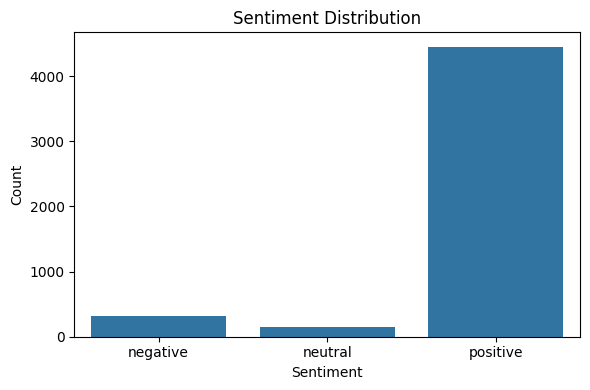

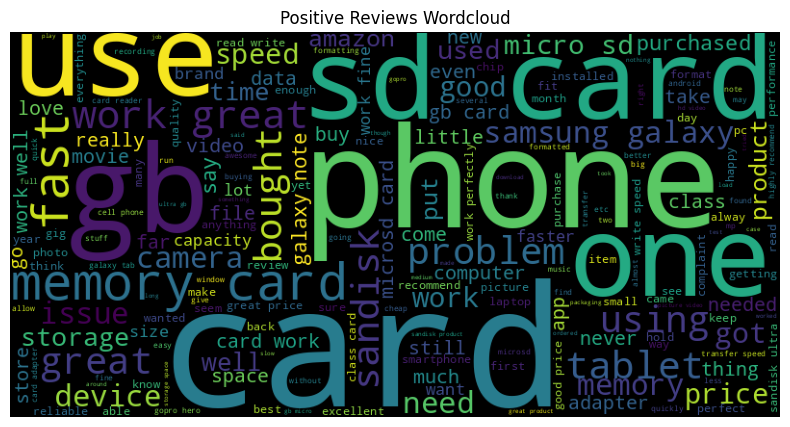

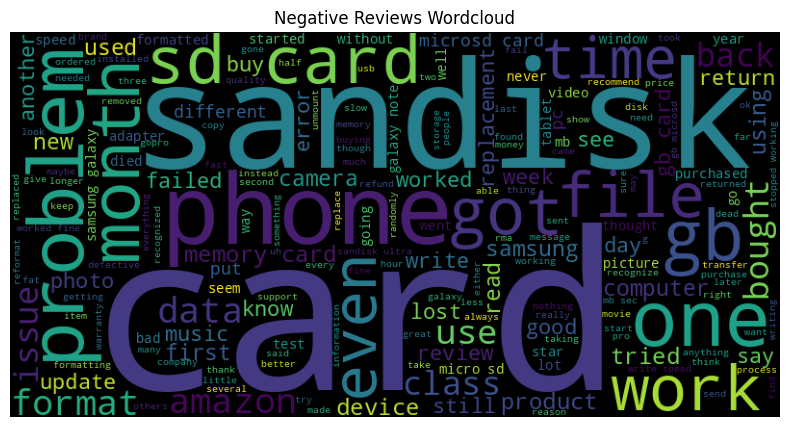


Logistic Regression — Accuracy: 0.9125  Precision: 0.9141  Recall: 0.9125  F1: 0.9130

Classification Report:
               precision    recall  f1-score   support

    negative       0.61      0.72      0.66        65
     neutral       0.08      0.07      0.08        28
    positive       0.96      0.95      0.96       890

    accuracy                           0.91       983
   macro avg       0.55      0.58      0.57       983
weighted avg       0.91      0.91      0.91       983


Naive Bayes — Accuracy: 0.8494  Precision: 0.9110  Recall: 0.8494  F1: 0.8722

Classification Report:
               precision    recall  f1-score   support

    negative       0.40      0.85      0.55        65
     neutral       0.10      0.18      0.13        28
    positive       0.97      0.87      0.92       890

    accuracy                           0.85       983
   macro avg       0.49      0.63      0.53       983
weighted avg       0.91      0.85      0.87       983



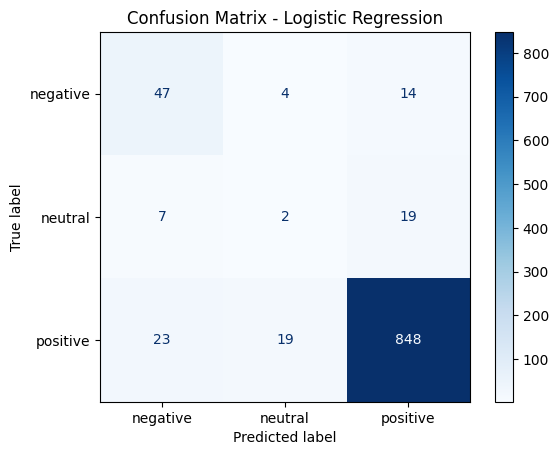


Saved: sentiment_model.pkl and tfidf_vectorizer.pkl

Example predictions:

Review: I love this product, it works perfectly!
Predicted sentiment: positive

Review: It's okay but not great.
Predicted sentiment: positive

Review: Terrible quality, broke after one use.
Predicted sentiment: positive

Pipeline completed.


In [47]:
# ---------------------------
# 9) Main flow (sequential and simple)
# ---------------------------
if __name__ == '__main__':
    # 1) Load data from CSV file named 'amazon.csv' in the same folder
    df = load_data('amazon.csv')

    # 2) Prepare dataframe: create labels and cleaned text
    df = prepare_dataframe(df)

    # 3) EDA visuals
    plot_sentiment_distribution(df)
    plot_wordclouds(df)

    # 4) Train models and evaluate. Set use_smote=False if you did not install imbalanced-learn
    artifacts = train_and_evaluate(df, use_smote=True)

    # 5) Try example predictions with saved logistic regression
    sample_reviews = [
        "I love this product, it works perfectly!",
        "It's okay but not great.",
        "Terrible quality, broke after one use."
    ]
    print('\nExample predictions:')
    predict_samples(artifacts['log_reg'], artifacts['vectorizer'], sample_reviews)

    print('\nPipeline completed.')


# Train/Test split

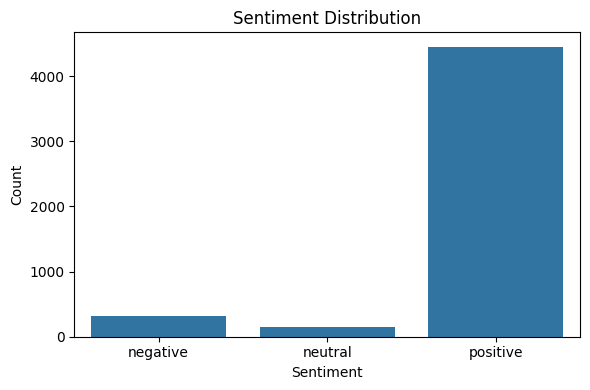

In [48]:
plot_sentiment_distribution(df)


#Bar chart showing counts of negative, neutral, and positive reviews

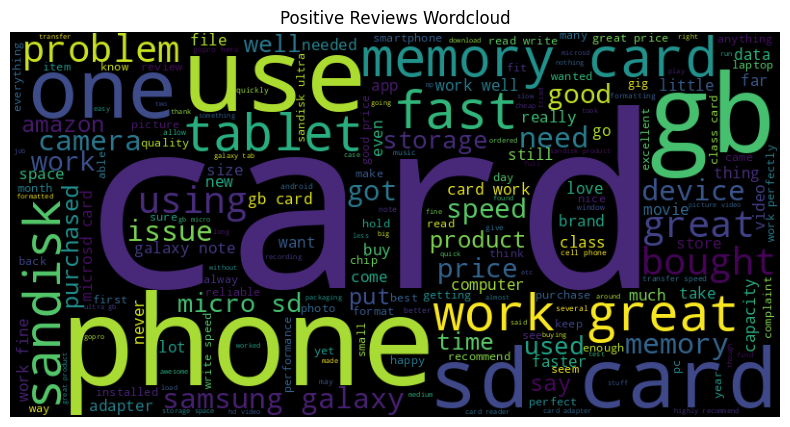

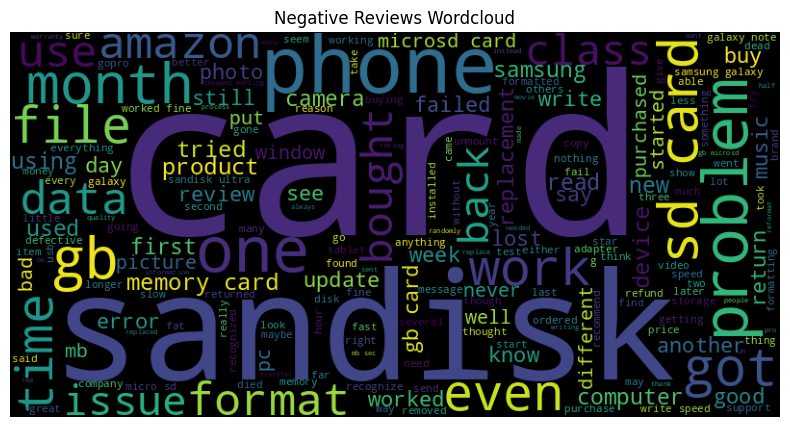

In [49]:
plot_wordclouds(df)


#Two word clouds: one for positive reviews, one for negative.

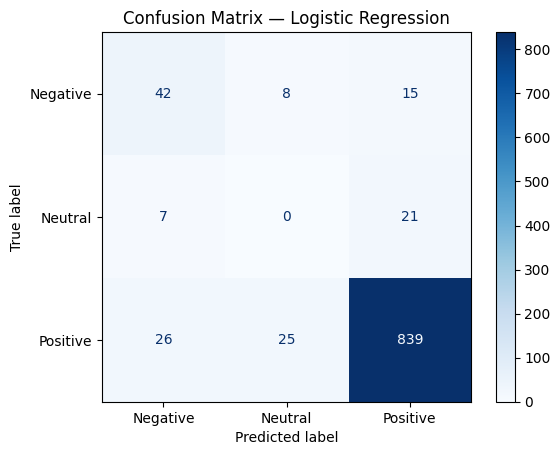

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


#ConfusionMatrixDisplay(...).plot()
# Assuming y_test and y_pred_lr exist from your logistic regression model
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Neutral','Positive'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

In [56]:
print(np.unique(y_test))
print(np.unique(y_pred_lr))

['negative' 'neutral' 'positive']
['negative' 'neutral' 'positive']
